Imports and Data Loading

In [43]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier, XGBRegressor

from sklearn.model_selection import GroupKFold

from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    mean_absolute_error,
    r2_score,
)

In [44]:
DATA_PATH = "dataset.parquet"

SENSOR_PREFIXES = (
    "IR_",
    "SCA_",
    "CV_",
)

GROUP_COL = "MET_ExperimentNumber"

MIN_POSITIVES = 12
MAX_NAN_FRAC = 0.50
N_SPLITS = 5
RANDOM_STATE = 42

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)

# Selected signals

In [45]:
df = pd.read_parquet(DATA_PATH)
print("DATASET OVERVIEW")
print("Shape :", df.shape)

label_cols = [c for c in df.columns if c.startswith("LBL_")]

print("\nMaterials")
print(df["MET_MaterialName"].value_counts())

print("\nExperiments")
print(df[GROUP_COL].nunique())

print("\nDefect Counts")
counts = (
    df[label_cols]
    .fillna(0)
    .astype(int)
    .sum()
    .sort_values(ascending=False)
)

print(counts)

DATASET OVERVIEW
Shape : (564, 334)

Materials
MET_MaterialName
PP     360
ABS    204
Name: count, dtype: int64

Experiments
30

Defect Counts
LBL_NOK              155
LBL_SinkMarks        143
LBL_SprueCircle       72
LBL_Underfilled       60
LBL_StreaksLevel3     48
LBL_StreaksLevel1     30
LBL_StreaksLevel2     18
LBL_OldGranulate       9
dtype: int64


### Feature Selection and Data Preprocessing

This step prepares the dataset for training the machine learning models by selecting relevant sensor features and handling missing values.

The preprocessing pipeline performs the following operations:

- Identifies sensor-related features based on predefined sensor prefixes.
- Retains only numerical sensor features, as machine learning algorithms require numerical inputs.
- Removes features with a high percentage of missing values (greater than the specified threshold).
- Creates the feature matrix (`X`) using the remaining sensor features.
- Replaces missing values in each feature with the median of that feature to preserve the dataset while reducing the influence of outliers.
- Adds an additional binary feature (`IS_PP`) that indicates whether the material type is polypropylene (PP).
- Creates the target matrix (`Y`) from the defect labels and replaces missing labels with 0.
- Stores the production group information for later use during grouped cross-validation.

Finally, the code displays summary statistics, including the size of the feature matrix, the number of remaining missing values, the number of retained features from each sensor type (IR, CV, and SCA), and the total number of features removed due to excessive missing data.

In [46]:
def is_sensor(col):
    return col.startswith(SENSOR_PREFIXES)

def is_numeric(col):
    return df[col].dtype.kind in "fiu"

sensor_cols = [
    c
    for c in df.columns
    if is_sensor(c) and is_numeric(c)
]

keep_cols = [
    c
    for c in sensor_cols
    if df[c].isnull().mean() <= MAX_NAN_FRAC
]

X = df[keep_cols].copy()

X = X.apply(
    lambda col: col.fillna(col.median()),
    axis=0,
)

X["IS_PP"] = (
    df["MET_MaterialName"] == "PP"
).astype(int)

Y = (
    df[label_cols]
    .fillna(0)
    .astype(int)
)

groups = df[GROUP_COL].values

print("\nFeature Matrix")

print(X.shape)

print("Remaining NaNs :", X.isnull().sum().sum())

print()

print("IR Features :", sum(c.startswith("IR_") for c in keep_cols))
print("CV Features :", sum(c.startswith("CV_") for c in keep_cols))
print("SCA Features :", sum(c.startswith("SCA_") for c in keep_cols))

print(
    "Dropped Features :",
    len(sensor_cols)-len(keep_cols)
)


Feature Matrix
(564, 85)
Remaining NaNs : 0

IR Features : 73
CV Features : 10
SCA Features : 1
Dropped Features : 1


### Selection of Trainable Defect Labels

Before training the classification models, the defect labels are evaluated to ensure that they contain a sufficient number of positive samples. Labels with at least the minimum required number of positive instances (`MIN_POSITIVES`) are selected for model training, while labels with fewer positive samples are excluded.

This filtering step is important because machine learning models require an adequate number of positive examples to learn meaningful decision boundaries. Labels with very few positive samples can lead to unstable models, poor generalization, and unreliable evaluation metrics.

The code also reports:
- **Trainable Labels:** Defect classes that satisfy the minimum sample requirement and will be used for training.
- **Skipped Labels:** Defect classes that do not have enough positive samples and are excluded from the analysis.

In [47]:
trainable = [
    c
    for c in label_cols
    if Y[c].sum() >= MIN_POSITIVES
]

skipped = [
    c
    for c in label_cols
    if c not in trainable
]

print("\nTrainable Labels")

print(
    [c.replace("LBL_","") for c in trainable]
)

print("\nSkipped Labels")

print(
    [c.replace("LBL_","") for c in skipped]
)


Trainable Labels
['NOK', 'SinkMarks', 'SprueCircle', 'StreaksLevel1', 'StreaksLevel2', 'StreaksLevel3', 'Underfilled']

Skipped Labels
['OldGranulate']


Build X

In [48]:
gkf = GroupKFold(
    n_splits=N_SPLITS
)

### Optimal Classification Threshold Selection

By default, many binary classification models classify a sample as positive when the predicted probability is greater than or equal to 0.5. However, this default threshold may not provide the best balance between precision and recall, especially when working with imbalanced datasets.

This function determines the optimal classification threshold by evaluating the Precision–Recall curve. For each possible threshold, the corresponding F1-score is calculated, and the threshold that produces the highest F1-score is selected.

The F1-score is defined as:

\[
F1 = \frac{2 \times (\text{Precision} \times \text{Recall})}
{\text{Precision} + \text{Recall}}
\]

where:
- **Precision** measures the proportion of correctly predicted positive samples.
- **Recall** measures the proportion of actual positive samples that are correctly identified.

Selecting the threshold that maximizes the F1-score provides a better trade-off between precision and recall than using the default threshold, making the classifier more suitable for defect detection where class imbalance is common.

In [49]:
def best_threshold(
    y_true,
    y_prob
):

    precision, recall, thresholds = precision_recall_curve(
        y_true,
        y_prob,
    )

    f1 = (
        2
        * precision
        * recall
        /
        (
            precision
            + recall
            + 1e-9
        )
    )

    idx = np.argmax(f1)

    if idx >= len(thresholds):
        return 0.50

    return float(thresholds[idx])

### XGBoost Classifier Configuration

This function creates and configures an XGBoost binary classifier that is used to train a separate model for each defect label. XGBoost was selected because it is an efficient gradient boosting algorithm capable of handling high-dimensional sensor data and capturing complex, non-linear relationships between process variables and defect occurrence.

The model is configured using a set of predefined hyperparameters, including the number of trees, learning rate, tree depth, regularization terms, and sampling ratios. These parameters are chosen to balance model accuracy while reducing the risk of overfitting.

The `scale_pos_weight` parameter is included to compensate for class imbalance by assigning greater importance to the minority (defect) class during training. This is particularly important because manufacturing defect datasets typically contain far fewer defective samples than normal samples.

A fixed random seed (`RANDOM_STATE`) is used to ensure that the training process is reproducible, while `n_jobs=-1` enables parallel computation using all available CPU cores to reduce training time.

The final print statement confirms that all preprocessing and model configuration steps have been completed successfully.

In [50]:
def make_clf(scale_pos_weight=1):

    return XGBClassifier(

        objective="binary:logistic",

        eval_metric="logloss",

        n_estimators=500,

        learning_rate=0.03,

        max_depth=5,

        min_child_weight=3,

        subsample=0.8,

        colsample_bytree=0.8,

        gamma=0.2,

        reg_alpha=0.1,

        reg_lambda=1,

        scale_pos_weight=scale_pos_weight,

        random_state=RANDOM_STATE,

        n_jobs=-1,
    )

print("\nPreprocessing Complete")


Preprocessing Complete


### XGBoost Model Training Initialization

This section marks the beginning of the XGBoost model training process. A separate binary classifier is trained for each eligible defect label using the prepared feature matrix.

Before training begins, several dictionaries are initialized to store the outputs generated during the modeling process:

- **`oof_probs`**: Stores the out-of-fold predicted probabilities obtained during cross-validation. These predictions are later used to evaluate model performance and determine the optimal classification threshold.
- **`thresholds`**: Stores the optimal probability threshold for each defect label, selected by maximizing the F1-score.
- **`final_models`**: Stores the trained XGBoost model for each defect class after the training process is completed.

The printed messages provide a clear indication that the model training stage has started.

In [51]:
print("TRAINING XGBOOST MODELS")
oof_probs = {}
thresholds = {}
final_models = {}

TRAINING XGBOOST MODELS


### Training XGBoost Models Using Grouped Cross-Validation

A separate XGBoost classifier is trained for each eligible defect label using **Group K-Fold cross-validation**. This validation strategy ensures that samples from the same production group are not split between the training and validation sets, reducing the risk of data leakage and providing a more realistic estimate of model performance.

For each defect label, the following steps are performed:

1. The binary target values corresponding to the current defect are extracted.
2. Group K-Fold cross-validation is applied to divide the data into training and validation folds.
3. Folds that contain no positive training examples are skipped, as a classifier cannot learn to recognize defects without positive samples.
4. The class imbalance ratio is calculated, and the `scale_pos_weight` parameter is adjusted accordingly to increase the importance of the minority (defect) class during training.
5. An XGBoost classifier is trained on the current training fold.
6. The trained model predicts the probability of defects for the corresponding validation fold, producing out-of-fold predictions.
7. After completing all folds, the optimal classification threshold is determined by maximizing the F1-score using the out-of-fold predictions.
8. Finally, a new XGBoost model is trained on the entire dataset using the same class-weighting strategy. This final model is stored and later used for feature importance analysis and predictions on unseen data.

This approach combines grouped cross-validation with class imbalance handling, producing robust performance estimates while minimizing overfitting and ensuring that each defect classifier is trained using all available data.

In [53]:
for label in trainable:

    print(f"\nTraining: {label}")

    y = Y[label].values

    oof = np.zeros(len(y))

    for fold, (tr, te) in enumerate(gkf.split(X, y, groups), start=1):

        # Skip folds with no positive examples
        if y[tr].sum() == 0:
            continue

        negatives = (y[tr] == 0).sum()
        positives = (y[tr] == 1).sum()

        scale_weight = negatives / max(positives, 1)

        clf = make_clf(scale_weight)

        clf.fit(
            X.iloc[tr],
            y[tr]
        )

        oof[te] = clf.predict_proba(
            X.iloc[te]
        )[:, 1]

        print(
            f"   Fold {fold} finished "
            f"(Pos={positives}, Neg={negatives})"
        )
    threshold = best_threshold(y, oof)

    thresholds[label] = threshold

    oof_probs[label] = oof
    negatives = (y == 0).sum()
    positives = (y == 1).sum()

    scale_weight = negatives / max(positives, 1)

    final_models[label] = make_clf(scale_weight)

    final_models[label].fit(X, y)

print("\n")
print("TRAINING COMPLETE")


Training: LBL_NOK
   Fold 1 finished (Pos=131, Neg=324)
   Fold 2 finished (Pos=107, Neg=337)
   Fold 3 finished (Pos=132, Neg=313)
   Fold 4 finished (Pos=119, Neg=337)
   Fold 5 finished (Pos=131, Neg=325)

Training: LBL_SinkMarks
   Fold 1 finished (Pos=119, Neg=336)
   Fold 2 finished (Pos=95, Neg=349)
   Fold 3 finished (Pos=120, Neg=325)
   Fold 4 finished (Pos=119, Neg=337)
   Fold 5 finished (Pos=119, Neg=337)

Training: LBL_SprueCircle
   Fold 1 finished (Pos=60, Neg=395)
   Fold 2 finished (Pos=36, Neg=408)
   Fold 3 finished (Pos=72, Neg=373)
   Fold 4 finished (Pos=72, Neg=384)
   Fold 5 finished (Pos=48, Neg=408)

Training: LBL_StreaksLevel1
   Fold 1 finished (Pos=30, Neg=425)
   Fold 2 finished (Pos=30, Neg=414)
   Fold 3 finished (Pos=6, Neg=439)
   Fold 4 finished (Pos=30, Neg=426)
   Fold 5 finished (Pos=24, Neg=432)

Training: LBL_StreaksLevel2
   Fold 1 finished (Pos=6, Neg=449)
   Fold 2 finished (Pos=18, Neg=426)
   Fold 3 finished (Pos=18, Neg=427)
   Fold 4 fin

### Model Performance Evaluation

After training, each XGBoost classifier is evaluated using the out-of-fold predictions obtained during Group K-Fold cross-validation. These predictions provide an unbiased estimate of model performance because each sample is evaluated by a model that was not trained on it.

For each defect label, the predicted probabilities are converted into binary predictions using the optimal classification threshold determined during the threshold optimization step. Several evaluation metrics are then calculated:

- **Number of Positive Samples:** The total number of defective instances for the current label.
- **Optimal Threshold:** The probability threshold that maximizes the F1-score.
- **F1-Score:** Measures the balance between precision and recall, making it particularly suitable for imbalanced defect classification problems.
- **ROC-AUC (Receiver Operating Characteristic – Area Under the Curve):** Evaluates the model's ability to distinguish between defective and non-defective samples across all classification thresholds.
- **PR-AUC (Precision–Recall Area Under the Curve):** Measures performance by considering the trade-off between precision and recall and is especially informative for imbalanced datasets.

The evaluation results are returned as a dictionary, allowing the performance metrics for each defect classifier to be easily summarized and compared.

In [54]:
def evaluate_label(label):

    y_true = Y[label].values

    y_prob = oof_probs[label]

    y_pred = (
        y_prob >= thresholds[label]
    ).astype(int)

    return {

        "positives": int(y_true.sum()),

        "threshold": round(
            thresholds[label],
            3,
        ),

        "F1": round(
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            ),
            3,
        ),

        "ROC_AUC": round(
            roc_auc_score(
                y_true,
                y_prob,
            ),
            3,
        ),

        "PR_AUC": round(
            average_precision_score(
                y_true,
                y_prob,
            ),
            3,
        ),
    }

### Summary of Cross-Validation Performance

After evaluating each XGBoost classifier, the performance metrics are collected into a single summary table (`scorecard`). Each row represents one defect class, while the columns contain the corresponding evaluation metrics.

The table includes the following information:

- **Positives:** Number of positive (defective) samples available for the defect class.
- **Threshold:** The optimal probability threshold selected by maximizing the F1-score.
- **F1-Score:** Measures the balance between precision and recall.
- **ROC-AUC:** Indicates the model's ability to distinguish between defective and non-defective samples.
- **PR-AUC:** Measures precision-recall performance, which is particularly informative for imbalanced datasets.

The scorecard is sorted in descending order of the **F1-score**, allowing the best-performing defect classifiers to appear first. This provides a concise overview of the classification performance across all trained defect models and facilitates comparison between defect classes.

In [55]:
scorecard = pd.DataFrame(

    {
        label.replace("LBL_", ""):
        evaluate_label(label)

        for label in trainable
    }

).T

scorecard = scorecard.sort_values(
    by="F1",
    ascending=False,
)

print("\n")
print("OUT OF FOLD PERFORMANCE")
print(scorecard)



OUT OF FOLD PERFORMANCE
               positives  threshold     F1  ROC_AUC  PR_AUC
SinkMarks          143.0      0.588  0.812    0.959   0.910
Underfilled         60.0      0.879  0.793    0.941   0.801
NOK                155.0      0.848  0.769    0.912   0.856
SprueCircle         72.0      0.874  0.667    0.837   0.671
StreaksLevel1       30.0      0.030  0.512    0.756   0.309
StreaksLevel3       48.0      0.476  0.500    0.907   0.524
StreaksLevel2       18.0      0.048  0.240    0.670   0.073


### Performance Comparison Across Defect Classes

To compare the effectiveness of the trained XGBoost classifiers, the evaluation metrics for each defect class are displayed as a grouped bar chart. Each group of bars corresponds to a defect class, while the individual bars represent different performance metrics.

The chart includes the following metrics:

- **F1-Score:** Evaluates the balance between precision and recall.
- **ROC-AUC:** Measures the model's ability to distinguish between positive and negative samples across all classification thresholds.
- **PR-AUC:** Evaluates the trade-off between precision and recall and is particularly useful for imbalanced classification problems.

Different colors are used to distinguish the evaluation metrics, making it easier to compare classifier performance across defect classes. The y-axis represents the metric values, which range from 0 to 1, with higher values indicating better predictive performance.

This visualization provides a clear overview of the strengths and weaknesses of each classifier and helps identify the defect classes that are predicted most accurately.

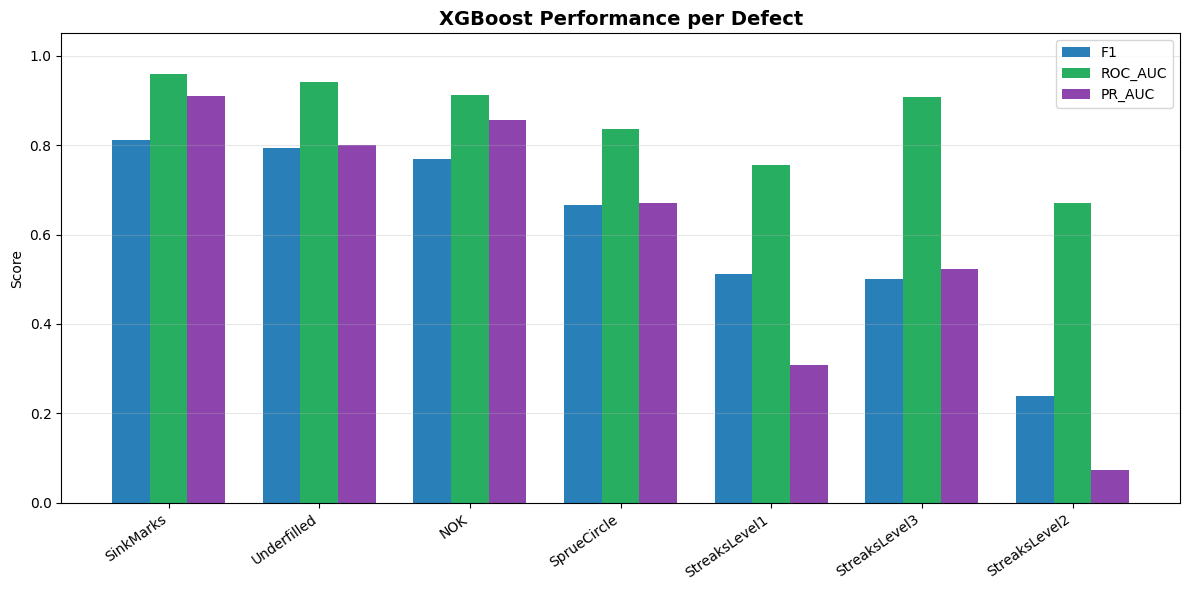

In [56]:
fig, ax = plt.subplots(figsize=(12, 6))

metrics = [
    "F1",
    "ROC_AUC",
    "PR_AUC",
]

colors = [
    "#2980b9",
    "#27ae60",
    "#8e44ad",
]

x = np.arange(len(scorecard))

width = 0.25

for i, metric in enumerate(metrics):

    ax.bar(
        x + (i - 1) * width,
        scorecard[metric],
        width,
        label=metric,
        color=colors[i],
    )

ax.set_xticks(x)

ax.set_xticklabels(
    scorecard.index,
    rotation=35,
    ha="right",
)

ax.set_ylim(0, 1.05)

ax.set_ylabel("Score")

ax.set_title(
    "XGBoost Performance per Defect",
    fontsize=14,
    fontweight="bold",
)

ax.grid(axis="y", alpha=0.3)

ax.legend()

plt.tight_layout()

plt.savefig(
    "xgboost_scorecard.png",
    dpi=150,
)

plt.show()

### Detailed Classification Reports

To provide a comprehensive evaluation of each trained XGBoost classifier, a detailed classification report is generated for every trainable defect label. The reports are based on the out-of-fold predictions obtained during Group K-Fold cross-validation and use the optimal probability threshold determined during threshold optimization.

For each defect class, the following information is displayed:

- **Optimal Threshold:** The probability threshold used to convert predicted probabilities into binary class predictions.
- **Precision:** The proportion of predicted defect samples that are actually defects.
- **Recall (Sensitivity):** The proportion of actual defects that are correctly identified by the classifier.
- **F1-Score:** The harmonic mean of precision and recall, providing a balanced measure of classification performance.
- **Support:** The number of samples belonging to each class (OK and DEFECT).

The classification report presents these metrics separately for both the **OK** (non-defective) and **DEFECT** classes, together with overall accuracy, macro averages, and weighted averages. This detailed evaluation complements the summary performance metrics by providing deeper insight into the strengths and limitations of each defect classifier.

In [57]:
print("\n")
print("CLASSIFICATION REPORTS")
for label in trainable:

    print("\n")

    print("-" * 60)

    print(label)

    print(
        "Threshold:",
        round(
            thresholds[label],
            3,
        )
    )

    pred = (

        oof_probs[label]
        >= thresholds[label]

    ).astype(int)

    print(

        classification_report(

            Y[label],

            pred,

            target_names=[
                "OK",
                "DEFECT",
            ],

            zero_division=0,

        )

    )

print("\nTraining and evaluation finished successfully.")



CLASSIFICATION REPORTS


------------------------------------------------------------
LBL_NOK
Threshold: 0.848
              precision    recall  f1-score   support

          OK       0.88      0.99      0.93       409
      DEFECT       0.95      0.65      0.77       155

    accuracy                           0.89       564
   macro avg       0.92      0.82      0.85       564
weighted avg       0.90      0.89      0.89       564



------------------------------------------------------------
LBL_SinkMarks
Threshold: 0.588
              precision    recall  f1-score   support

          OK       0.92      0.97      0.94       421
      DEFECT       0.90      0.74      0.81       143

    accuracy                           0.91       564
   macro avg       0.91      0.86      0.88       564
weighted avg       0.91      0.91      0.91       564



------------------------------------------------------------
LBL_SprueCircle
Threshold: 0.874
              precision    recall  f1-score

In [58]:
print("FEATURE IMPORTANCE")

def feature_source(name):

    if name.startswith("IR_"):
        return "IR"

    elif name.startswith("CV_"):
        return "CV"

    elif name.startswith("SCA_"):
        return "SCA"

    return "MAT"


source_color = {

    "IR": "#9b59b6",

    "CV": "#16a085",

    "SCA": "#e67e22",

    "MAT": "#95a5a6",

}

FEATURE IMPORTANCE


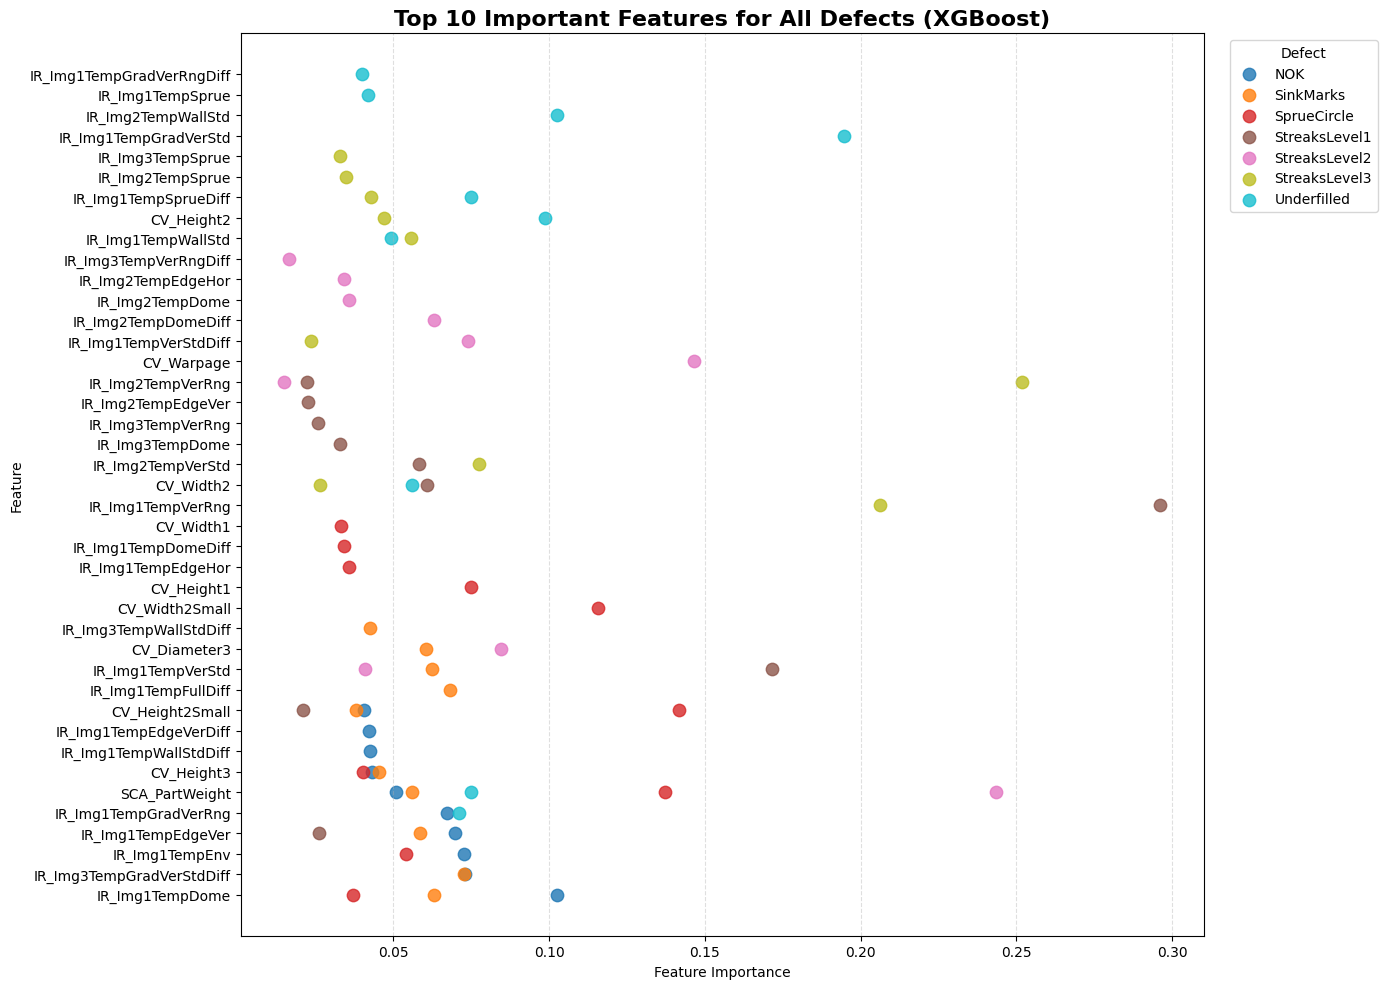

In [59]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
rows = []

for label, model in final_models.items():
    importance = pd.Series(
        model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False).head(10)

    for feature, value in importance.items():
        rows.append({
            "Defect": label.replace("LBL_", ""),
            "Feature": feature,
            "Importance": value
        })

importance_df = pd.DataFrame(rows)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

defects = importance_df["Defect"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(defects)))

for color, defect in zip(colors, defects):

    temp = importance_df[importance_df["Defect"] == defect]

    ax.scatter(
        temp["Importance"],
        temp["Feature"],
        s=80,
        color=color,
        label=defect,
        alpha=0.8
    )

ax.set_title(
    "Top 10 Important Features for All Defects (XGBoost)",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")

ax.grid(axis="x", linestyle="--", alpha=0.4)

ax.legend(
    title="Defect",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.savefig("combined_feature_importance.png", dpi=200)
plt.show()

In [60]:
print("TOP 5 FEATURES")
for label, model in final_models.items():

    print("\n")

    print(label.replace("LBL_", ""))

    importance = (

        pd.Series(

            model.feature_importances_,

            index=X.columns,

        )

        .sort_values(ascending=False)

        .head(5)

    )

    print(importance)


TOP 5 FEATURES


NOK
IR_Img1TempDome              0.102487
IR_Img3TempGradVerStdDiff    0.073009
IR_Img1TempEnv               0.072660
IR_Img1TempEdgeVer           0.069841
IR_Img1TempGradVerRng        0.067390
dtype: float32


SinkMarks
IR_Img3TempGradVerStdDiff    0.072733
IR_Img1TempFullDiff          0.068106
IR_Img1TempDome              0.063014
IR_Img1TempVerStd            0.062358
CV_Diameter3                 0.060653
dtype: float32


SprueCircle
CV_Height2Small    0.141617
SCA_PartWeight     0.137215
CV_Width2Small     0.115682
CV_Height1         0.074851
IR_Img1TempEnv     0.054016
dtype: float32


StreaksLevel1
IR_Img1TempVerRng    0.296034
IR_Img1TempVerStd    0.171644
CV_Width2            0.060924
IR_Img2TempVerStd    0.058172
IR_Img3TempDome      0.032880
dtype: float32


StreaksLevel2
SCA_PartWeight           0.243383
CV_Warpage               0.146595
CV_Diameter3             0.084533
IR_Img1TempVerStdDiff    0.074046
IR_Img2TempDomeDiff      0.062945
dtype: float32


Stre

### Generation and Export of Prediction Results

After evaluating the trained XGBoost classifiers, the prediction results are compiled into a single table at the machine cycle level. This table combines the original metadata with the model predictions, making it suitable for further analysis and validation.

For each trainable defect class, the following information is recorded:

- **Predicted Probability (`PROB_`)**: The probability assigned by the XGBoost classifier that the machine cycle contains the corresponding defect.
- **Predicted Label (`PRED_`)**: The binary prediction obtained by applying the optimal classification threshold to the predicted probability.
- **True Label (`TRUE_`)**: The actual defect label from the dataset, used for comparison with the model predictions.

In addition, an overall defect indicator (`PRED_ANY_DEFECT`) is created. This variable is assigned a value of **1** if at least one defect is predicted for a machine cycle; otherwise, it is assigned **0**. This provides a simple way to identify whether a production cycle is predicted to contain any defect.

Finally, the complete prediction table is exported as **`predictions_per_cycle.csv`**, allowing the results to be used for further analysis, visualization, or integration into downstream quality monitoring systems.

In [61]:
preds = pd.DataFrame({

    "MET_MachineCycleID":

        df["MET_MachineCycleID"].values,

    "MET_ExperimentNumber":

        df[GROUP_COL].values,

    "MET_MaterialName":

        df["MET_MaterialName"].values,

})

for label in trainable:

    short = label.replace("LBL_", "")

    probability = oof_probs[label]

    prediction = (

        probability >= thresholds[label]

    ).astype(int)

    preds[f"PROB_{short}"] = probability.round(3)

    preds[f"PRED_{short}"] = prediction

    preds[f"TRUE_{short}"] = Y[label].values

prediction_columns = [

    c

    for c in preds.columns

    if c.startswith("PRED_")

]

preds["PRED_ANY_DEFECT"] = (

    preds[prediction_columns]

    .sum(axis=1)

    .gt(0)

    .astype(int)

)

preds.to_csv(

    "predictions_per_cycle.csv",

    index=False,

)

print("\nSaved predictions_per_cycle.csv")

print(preds.head())



Saved predictions_per_cycle.csv
   MET_MachineCycleID MET_ExperimentNumber MET_MaterialName  PROB_NOK  PRED_NOK  TRUE_NOK  PROB_SinkMarks  PRED_SinkMarks  TRUE_SinkMarks  \
0               18535                  A16               PP     0.009         0         1           0.024               0               1   
1               18536                  A16               PP     0.012         0         1           0.085               0               1   
2               18537                  A16               PP     0.015         0         1           0.108               0               1   
3               18538                  A16               PP     0.012         0         1           0.075               0               1   
4               18539                  A16               PP     0.010         0         1           0.034               0               1   

   PROB_SprueCircle  PRED_SprueCircle  TRUE_SprueCircle  PROB_StreaksLevel1  PRED_StreaksLevel1  TRUE_StreaksLevel1  PRO

### Predicting Defects for New Sensor Data

Once the XGBoost models have been trained, they can be used to predict defects in previously unseen production data. This function provides a reusable prediction pipeline that applies the trained classifiers to new sensor measurements.

The prediction process consists of the following steps:

1. The input data is aligned with the feature set used during model training to ensure consistency.
2. Any missing feature values are replaced with the median value of the corresponding feature.
3. Each trained XGBoost classifier predicts the probability that a defect is present.
4. The predicted probabilities are converted into binary defect predictions using the optimal threshold determined during model evaluation.
5. The predicted labels for all defect classes are returned as a single DataFrame, where each column corresponds to a defect type and each row represents a production cycle.

This function enables the trained models to be deployed for quality prediction on new manufacturing data without requiring retraining.

In [62]:
def predict_quality(rows):

    """
    Predict defect labels
    for unseen sensor rows.
    """

    features = rows.reindex(

        columns=X.columns

    )

    features = features.apply(

        lambda col:

        col.fillna(col.median()),

        axis=0,

    )

    output = {}

    for label, model in final_models.items():

        probability = model.predict_proba(

            features

        )[:, 1]

        prediction = (

            probability

            >= thresholds[label]

        ).astype(int)

        output[

            label.replace("LBL_", "")

        ] = prediction

    return pd.DataFrame(

        output,

        index=rows.index,

    )

### Warpage Prediction Using XGBoost Regression

In addition to defect classification, an XGBoost regression model is developed to predict the **warpage measurement** (`CV_Warpage`), which is a continuous quality characteristic of the manufactured component.

Separate regression models are trained for the **PP** and **ABS** materials because the relationship between process variables and warpage may differ between materials.

The regression workflow consists of the following steps:

1. The target variable (`CV_Warpage`) is excluded from the input feature set to prevent data leakage.
2. The dataset is filtered to include only samples of the selected material with valid warpage measurements.
3. **Group K-Fold cross-validation** is applied to ensure that production groups remain separated between the training and validation sets.
4. An XGBoost regressor is trained on each training fold and used to predict warpage values for the corresponding validation fold.
5. Out-of-fold predictions are combined to evaluate the model using all available samples.

The regression performance is assessed using two evaluation metrics:

- **Mean Absolute Error (MAE):** Measures the average absolute difference between the predicted and actual warpage values. Lower values indicate better prediction accuracy.
- **Coefficient of Determination (R²):** Measures how well the model explains the variability of the warpage measurements. Values closer to **1** indicate better predictive performance, while values near or below **0** indicate poor model performance.

The evaluation is performed separately for PP and ABS materials, allowing the predictive capability of the model to be compared across different manufacturing conditions.

In [63]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold
import numpy as np

def make_reg():
    return XGBRegressor(
        objective="reg:squarederror",
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.2,
        reg_alpha=0.1,
        reg_lambda=1,
        random_state=42,
        n_jobs=-1,
    )

warp_feats = [c for c in X.columns if c != "CV_Warpage"]
print("XGBOOST REGRESSION RESULTS")

for material in ["PP", "ABS"]:

    mask = (
        (df["MET_MaterialName"] == material)
        & (df["CV_Warpage"].notna())
    )

    x_mat = X.loc[mask, warp_feats]
    y_mat = df.loc[mask, "CV_Warpage"].values
    g_mat = df.loc[mask, GROUP_COL].values

    oof_pred = np.zeros(len(y_mat))

    gkf = GroupKFold(n_splits=5)

    for train_idx, test_idx in gkf.split(x_mat, y_mat, g_mat):

        model = make_reg()

        model.fit(
            x_mat.iloc[train_idx],
            y_mat[train_idx]
        )

        oof_pred[test_idx] = model.predict(
            x_mat.iloc[test_idx]
        )

    mae = mean_absolute_error(y_mat, oof_pred)
    r2 = r2_score(y_mat, oof_pred)

    print(f"\nMaterial : {material}")
    print(f"Samples  : {len(y_mat)}")
    print(f"MAE      : {mae:.4f} mm")
    print(f"R² Score : {r2:.4f}")

XGBOOST REGRESSION RESULTS

Material : PP
Samples  : 360
MAE      : 0.2313 mm
R² Score : 0.2620

Material : ABS
Samples  : 204
MAE      : 0.1454 mm
R² Score : 0.3743


### Demonstration of Defect Prediction

To demonstrate the functionality of the trained prediction pipeline, a random sample of five production cycles is selected from the prepared feature dataset. These samples are passed to the `predict_quality()` function, which generates predicted defect labels using the trained XGBoost classifiers.

The predicted labels are further summarized into a single descriptive column (`PREDICTED_DEFECTS`), providing an easy-to-read overview of the detected defects for each sample.

Finally, the predicted defect labels are compared with the corresponding ground truth labels from the original dataset. The resulting comparison table displays the **actual** and **predicted** defect labels side by side, allowing a qualitative assessment of the model's prediction accuracy on unseen samples.

This example illustrates how the trained models can be used to perform defect prediction on new manufacturing data and demonstrates the complete inference workflow developed in this study.

In [64]:
sample = X.sample(5, random_state=42)

demo = predict_quality(sample)

demo["PREDICTED_DEFECTS"] = demo.apply(summarize, axis=1)

demo

,NOK,SinkMarks,SprueCircle,StreaksLevel1,StreaksLevel2,StreaksLevel3,Underfilled,PREDICTED_DEFECTS
537,0,0,0,0,0,0,0,OK
522,0,0,0,0,0,0,0,OK
234,0,0,0,0,0,1,0,StreaksLevel3
523,0,0,0,0,0,0,0,OK
485,0,0,0,0,0,0,0,OK


In [65]:
idx = sample.index

comparison = pd.concat(
    [
        Y.loc[idx].reset_index(drop=True),
        demo.reset_index(drop=True)
    ],
    axis=1,
    keys=["True", "Predicted"]
)

comparison

True                                                                                                                      Predicted            \
  LBL_NOK LBL_OldGranulate LBL_SinkMarks LBL_SprueCircle LBL_StreaksLevel1 LBL_StreaksLevel2 LBL_StreaksLevel3 LBL_Underfilled       NOK SinkMarks   
0       0                0             0               0                 0                 0                 0               0         0         0   
1       0                0             0               0                 0                 0                 0               0         0         0   
2       0                0             0               0                 0                 0                 1               0         0         0   
3       0                0             0               0                 0                 0                 0               0         0         0   
4       0                0             0               0                 0                 0                 0               0         0         0   

                                                                                       
  SprueCircle StreaksLevel1 StreaksLevel2 StreaksLevel3 Underfilled PREDICTED_DEFECTS  
0           0             0             0             0           0                OK  
1           0             0             0             0           0                OK  
2           0             0             0             1           0     StreaksLevel3  
3           0             0             0             0           0                OK  
4           0             0             0             0           0                OK

### Confusion Matrix for Each Defect Class

To further evaluate the classification performance, a confusion matrix is generated for each trained defect classifier. The confusion matrix compares the actual defect labels with the predicted labels obtained using the optimal classification threshold.

For each defect class, the table reports:

- **True Negatives (TN):** Non-defective samples correctly classified as OK.
- **False Positives (FP):** Non-defective samples incorrectly classified as defects.
- **False Negatives (FN):** Defective samples incorrectly classified as OK.
- **True Positives (TP):** Defective samples correctly identified by the classifier.

The confusion matrix provides a detailed view of prediction outcomes and helps identify the types of errors made by each model. This information complements the evaluation metrics such as F1-score, ROC-AUC, and PR-AUC by showing the exact number of correct and incorrect classifications for every defect class.

In [66]:
for label in trainable:

    pred = (oof_probs[label] >= thresholds[label]).astype(int)

    print(label)

    print(pd.crosstab(
        Y[label],
        pred,
        rownames=["True"],
        colnames=["Predicted"]
    ))

    print()

LBL_NOK
Predicted    0    1
True               
0          404    5
1           55  100

LBL_SinkMarks
Predicted    0    1
True               
0          409   12
1           37  106

LBL_SprueCircle
Predicted    0   1
True              
0          492   0
1           36  36

LBL_StreaksLevel1
Predicted    0   1
True              
0          503  31
1            9  21

LBL_StreaksLevel2
Predicted    0   1
True              
0          520  26
1           12   6

LBL_StreaksLevel3
Predicted    0   1
True              
0          510   6
1           30  18

LBL_Underfilled
Predicted    0   1
True              
0          491  13
1           12  48



# Conclusion

This study investigated the use of XGBoost for both defect classification and warpage prediction using sensor data collected from an injection molding manufacturing process. The objective was to develop a data-driven quality prediction system capable of identifying multiple defect types while also estimating the continuous warpage measurement of manufactured parts.

For the classification task, separate XGBoost classifiers were trained for each defect type using **Group K-Fold cross-validation**, ensuring that samples from the same production group were not shared between the training and validation sets. This evaluation strategy reduced the risk of data leakage and provided a more realistic estimate of model performance.

The classification results demonstrate that the proposed approach successfully identified several manufacturing defects. Based on the confusion matrices, the classification accuracies ranged from approximately **89.4% to 95.6%** across the different defect classes. Among the evaluated defects, **Underfilled** achieved the highest accuracy (95.57%), while **SinkMarks**, **SprueCircle**, and the **Streaks** defect levels also showed strong classification performance. Although defects such as **SprueCircle** and **StreaksLevel3** exhibited a larger number of false negatives, the models were still able to correctly detect many defective samples. Since the dataset is imbalanced, the models were primarily evaluated using **F1-score**, **ROC-AUC**, and **PR-AUC**, which provide a more reliable assessment than accuracy alone.

The confusion matrices further confirmed that the classifiers correctly identified the majority of non-defective production cycles while maintaining good detection capability for defective parts. These results indicate that the selected sensor features contain meaningful information for distinguishing between normal and defective manufacturing conditions.

The prediction pipeline was further validated using a randomly selected set of production cycles. The comparison between the predicted and true labels showed that all five demonstration samples were classified correctly. Four samples were accurately identified as defect-free (**OK**), while one sample containing a **StreaksLevel3** defect was correctly detected. This demonstrates that the developed inference pipeline can successfully predict defect labels for previously unseen manufacturing data.

In addition to defect classification, XGBoost regression models were developed to predict the continuous **CV_Warpage** measurement separately for **PP** and **ABS** materials. The regression results showed:

| Material | MAE (mm) | R² Score |
|----------|---------:|---------:|
| PP | 0.2313 | 0.2620 |
| ABS | 0.1454 | 0.3743 |

The regression model achieved better performance for the **ABS** material, obtaining both a lower Mean Absolute Error (0.1454 mm) and a higher R² score (0.3743) than the PP model. Although the regression models successfully captured part of the relationship between the process variables and product warpage, the relatively modest R² values indicate that additional process parameters or more advanced feature engineering may further improve prediction accuracy.

Overall, the results demonstrate that **XGBoost is an effective machine learning approach for manufacturing quality prediction**. The classification models achieved strong performance across multiple defect categories, while the regression models produced reasonable estimates of product warpage. Furthermore, the successful prediction of unseen production samples confirms the practical applicability of the developed prediction pipeline. Future work could focus on hyperparameter optimization, feature engineering, additional sensor integration, and the investigation of ensemble or deep learning approaches to further improve both classification and regression performance.